# EDA - Exploratory Data Analysis e Preparação de Dados
**Importando bibliotecas**

In [77]:
import pandas as pd
import jinja2
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import silhouette_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.cluster import KMeans

# 1 - Formatação dos Atributos 
**Identifique os atributos faltantes, chamados agora de atributos-alvo, bem como identifique as tuplas que possuem esses atributos faltantes. Você pode criar uma lista com os ids dessas tuplas para facilitar.**


In [78]:
# Carregando o Dataset e analisando as colunas disponíveis
df = pd.read_csv("Titanic-Dataset-Modificado.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1069 entries, 0 to 1068
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1069 non-null   int64  
 1   Survived     1069 non-null   bool   
 2   Pclass       985 non-null    float64
 3   Name         1069 non-null   object 
 4   Sex          985 non-null    object 
 5   Age          855 non-null    object 
 6   SibSp        1069 non-null   int64  
 7   Parch        1069 non-null   int64  
 8   Ticket       1069 non-null   object 
 9   Fare         1069 non-null   float64
 10  Cabin        248 non-null    object 
 11  Embarked     983 non-null    object 
 12  day          1069 non-null   int64  
 13  month        1069 non-null   int64  
 14  year         1069 non-null   int64  
 15  time         1069 non-null   object 
 16  cost         202 non-null    float64
 17  budget       128 non-null    float64
dtypes: bool(1), float64(4), int64(6), object(7)
memo

Nesse arquivo podemos notar que há 18 colunas, das quais: 
- **PassengerId**: é um identificador que não é necessário aqui (drop)
- **Survived**: coluna alvo (booleano), conversão 0/1
- **Pclass**: classe que representam as passagens (1, 2, 3), numérica ordinal com valores faltantes
- **Name**: texto livre (drop)
- **Sex**: categoria nominal com valores faltantes
- **Age**: precisa de padronização em sua representação e possui valores faltantes
- **SibSp**: numérico
- **Parch**: numérico
- **Ticket**: código alfanumérico s/ padrão, não há utilidade nesse projeto (drop)
- **Fare**: numérico contínuo (tarifas)
- **Cabin**: muitos valores faltantes (drop)
- **Embarked**: categoria nominal, valores faltantes
- **day**: não há relação interessante para uso nesse projeto, (drop)
- **month**: não há relação interessante para uso nesse projeto, (drop)
- **year**: numérico constante, mas não há relação interessante para uso nesse projeto, (drop)
- **time**: não há relação interessante para uso nesse projeto, (drop)
- **cost**: muitos dados faltantes
- **budget**: muitos dados faltantes

In [79]:
df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin', 'day', 'month', 'year', 'time', 'cost', 'budget'], inplace=True)
# Sobram as seguintes colunas
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1069 entries, 0 to 1068
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  1069 non-null   bool   
 1   Pclass    985 non-null    float64
 2   Sex       985 non-null    object 
 3   Age       855 non-null    object 
 4   SibSp     1069 non-null   int64  
 5   Parch     1069 non-null   int64  
 6   Fare      1069 non-null   float64
 7   Embarked  983 non-null    object 
dtypes: bool(1), float64(2), int64(2), object(3)
memory usage: 59.6+ KB


In [80]:
# Formatos da coluna 'age' (precisa ser padronizado)
df['Age'].dropna().unique()[:30]

array(['22 years old', 'Age 38', '26', '35', '35 years old',
       '54 years old', '2 years old', 'Age 27', 'Age 14', 'estimated 4',
       '58', 'Age 20', '39', '~14 yo', 'Age 55', '31', 'estimated 35',
       '34 years old', '15.0', '28', '8 years old', '38 years old',
       '19.0', '40', '66.0', 'Age 28', '42 years old', '21.0',
       '18 years old', '14.0'], dtype=object)

In [81]:
# Distribuição das classes da coluna alvo
df['Survived'].value_counts()

Survived
False    654
True     415
Name: count, dtype: int64

# Padronizando o formato dos atributos
- **Age**: transformar os valores em numéricos, ao invés de strings 
- **Sex**: categoria nominal com valores faltantes, logo é mais interessante transformar em variável nominal binária (0 para homens, 1 para mulheres)
- **Embarked**: nominal que será tratada para visualização numérica, depois do K means
- **Pclass**: numérica ordinal, não é necessária uma transformação de formato categórico
- **Survived**: de booleano para inteiro

In [82]:
def parse_age(v):
    if pd.isna(v):
        return np.nan
    m = re.search(r'(\d+\.?\d*)', str(v)) # Regex que busca o primeiro número inteiro ou decimal dentro da string
    # Ver infos abaixo
    return float(m.group(1)) if m else np.nan

# Age
df['Age'] = df['Age'].apply(parse_age)
# Sex
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
# Survived
df['Survived'] = df['Survived'].astype(int)

df.dtypes

Survived      int64
Pclass      float64
Sex         float64
Age         float64
SibSp         int64
Parch         int64
Fare        float64
Embarked     object
dtype: object

# Solução via IA Claude
A linha de código:
 m = re.search(r'(\d+\.?\d*)', str(v))

É uma solução encontrada via IA Claude que busca o primeiro número decimal dentro da string. Minha dúvida era sobre como padronizar procurando os números dentre as strings sem que eu precisasse buscar por um código muito extenso.

Para a coluna 'Age' que estava totalmente bagunçada ele captura exatamente os valores necessários (numéricos).

- \d+ — um ou mais dígitos (parte inteira, obrigatória)
- \.? — um ponto decimal opcional
- \d* — zero ou mais dígitos depois do ponto (parte decimal, opcional)
- E os parênteses (...) criam um grupo de captura, que depois é acessado com m.group(1)

In [83]:
# Para remover as linhas que estão duplicadas
linhas_antes = df.shape[0]
df = df.drop_duplicates().reset_index(drop=True)
print(f'Linhas duplicadas removidas: {linhas_antes - df.shape[0]}')
print(f'Estrutura atual: {df.shape}')



Linhas duplicadas removidas: 286
Estrutura atual: (783, 8)


In [38]:
# Dados faltantes
df.isnull().sum()

Survived      0
Pclass       67
Sex          67
Age         106
SibSp         0
Parch         0
Fare          0
Embarked     69
dtype: int64

# 2 - Análise e escolha dos atributos
**Gere uma versão do dataset sem os atributos-alvo. É muito importante que neste recorte, que chamaremos de dataset2, todas as tuplas selecionadas possuam dados em todos os seus atributos.**

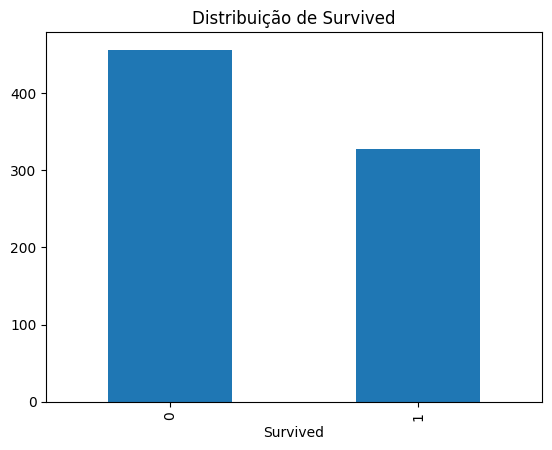

In [84]:
# Variável alvo
df['Survived'].value_counts().plot(kind='bar')
plt.title('Distribuição de Survived')
plt.show()

In [85]:
# Taxa de sobrevivência por classe (Pclass)
df.groupby('Pclass')['Survived'].mean()

Pclass
1.0    0.572222
2.0    0.460000
3.0    0.227979
Name: Survived, dtype: float64

In [86]:
# Taxa de sobrevivência por sexo
df.groupby('Sex')['Survived'].mean()

Sex
0.0    0.188034
1.0    0.693548
Name: Survived, dtype: float64

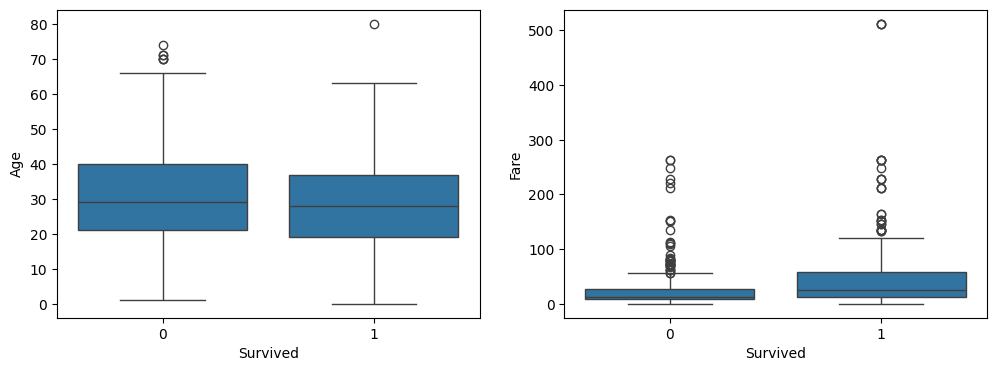

In [87]:
# Distribuição de Age e Fare por sobrevivência
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.boxplot(data=df, x='Survived', y='Age', ax=axes[0])
sns.boxplot(data=df, x='Survived', y='Fare', ax=axes[1])
plt.show()

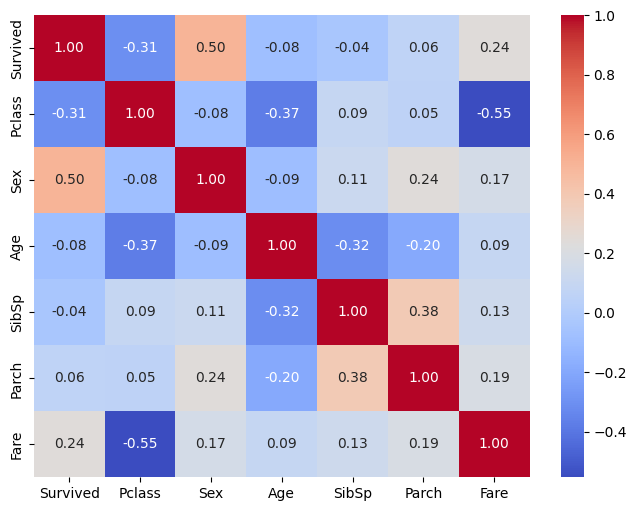

In [88]:
# Matriz de correlação entre os atributos numéricos
plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

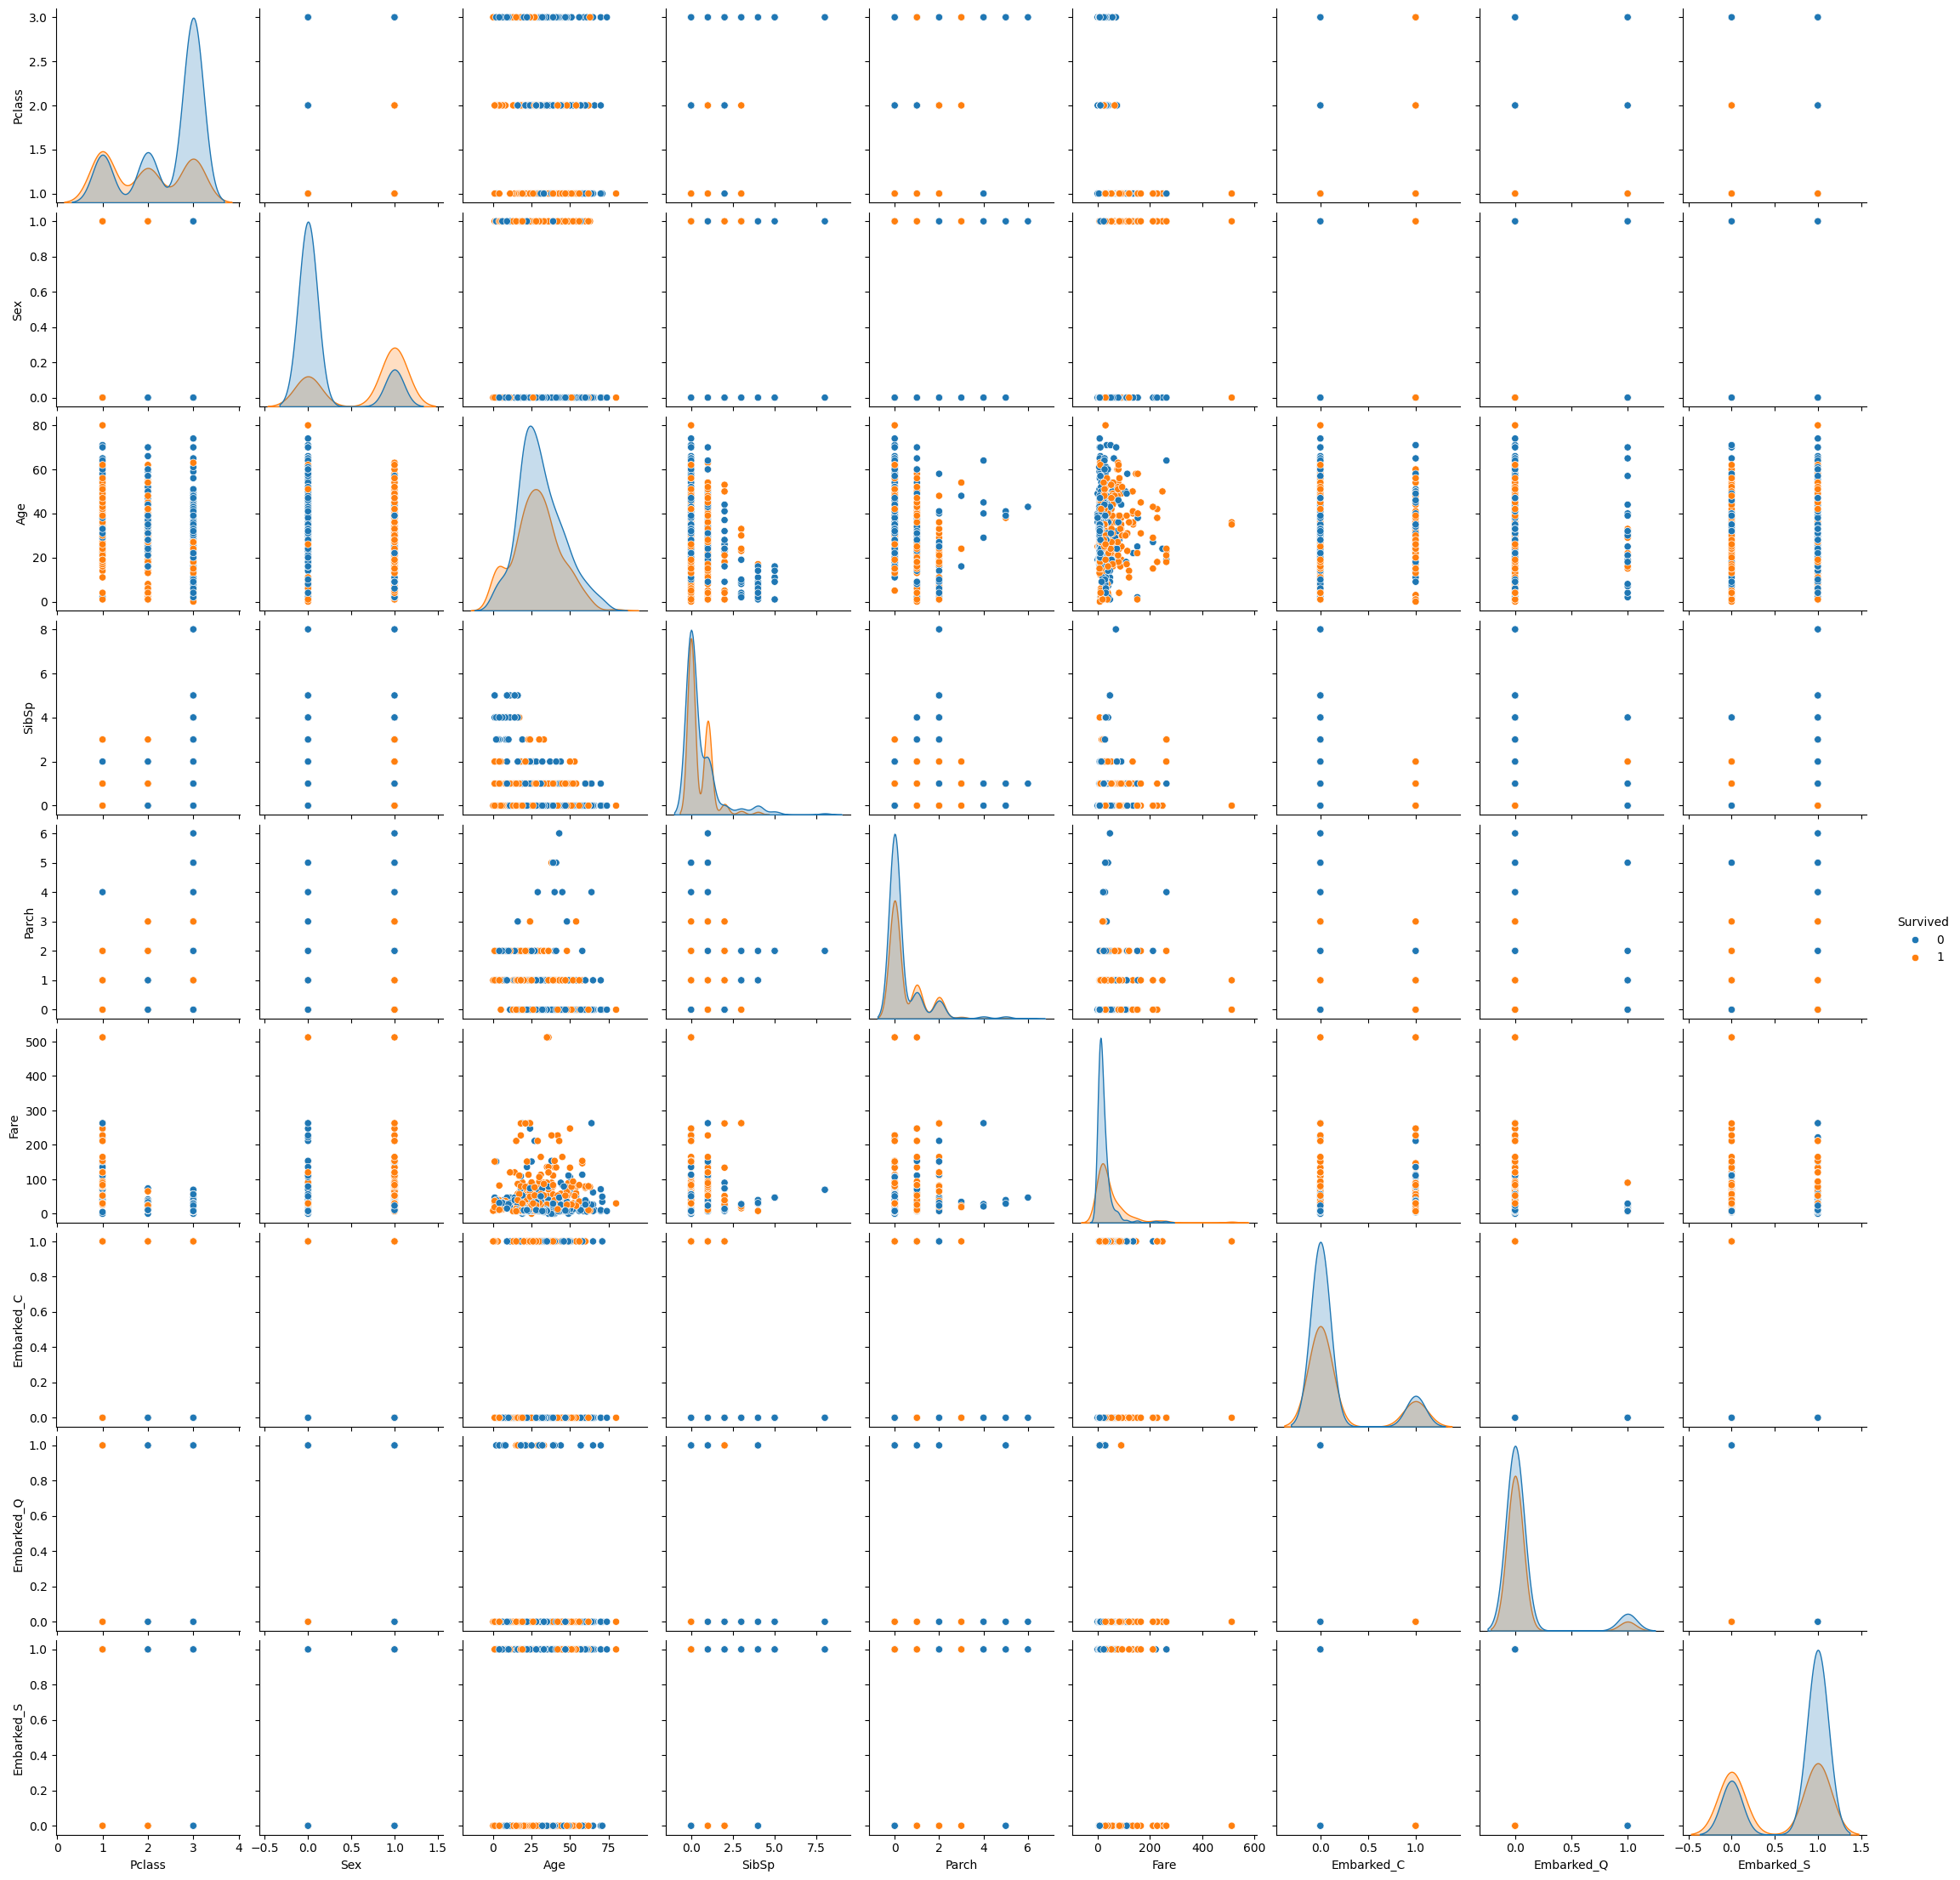

In [89]:
df_viz = pd.get_dummies(df, columns=['Embarked'], dtype=int)
sns.pairplot(df_viz, hue='Survived')
plt.show()

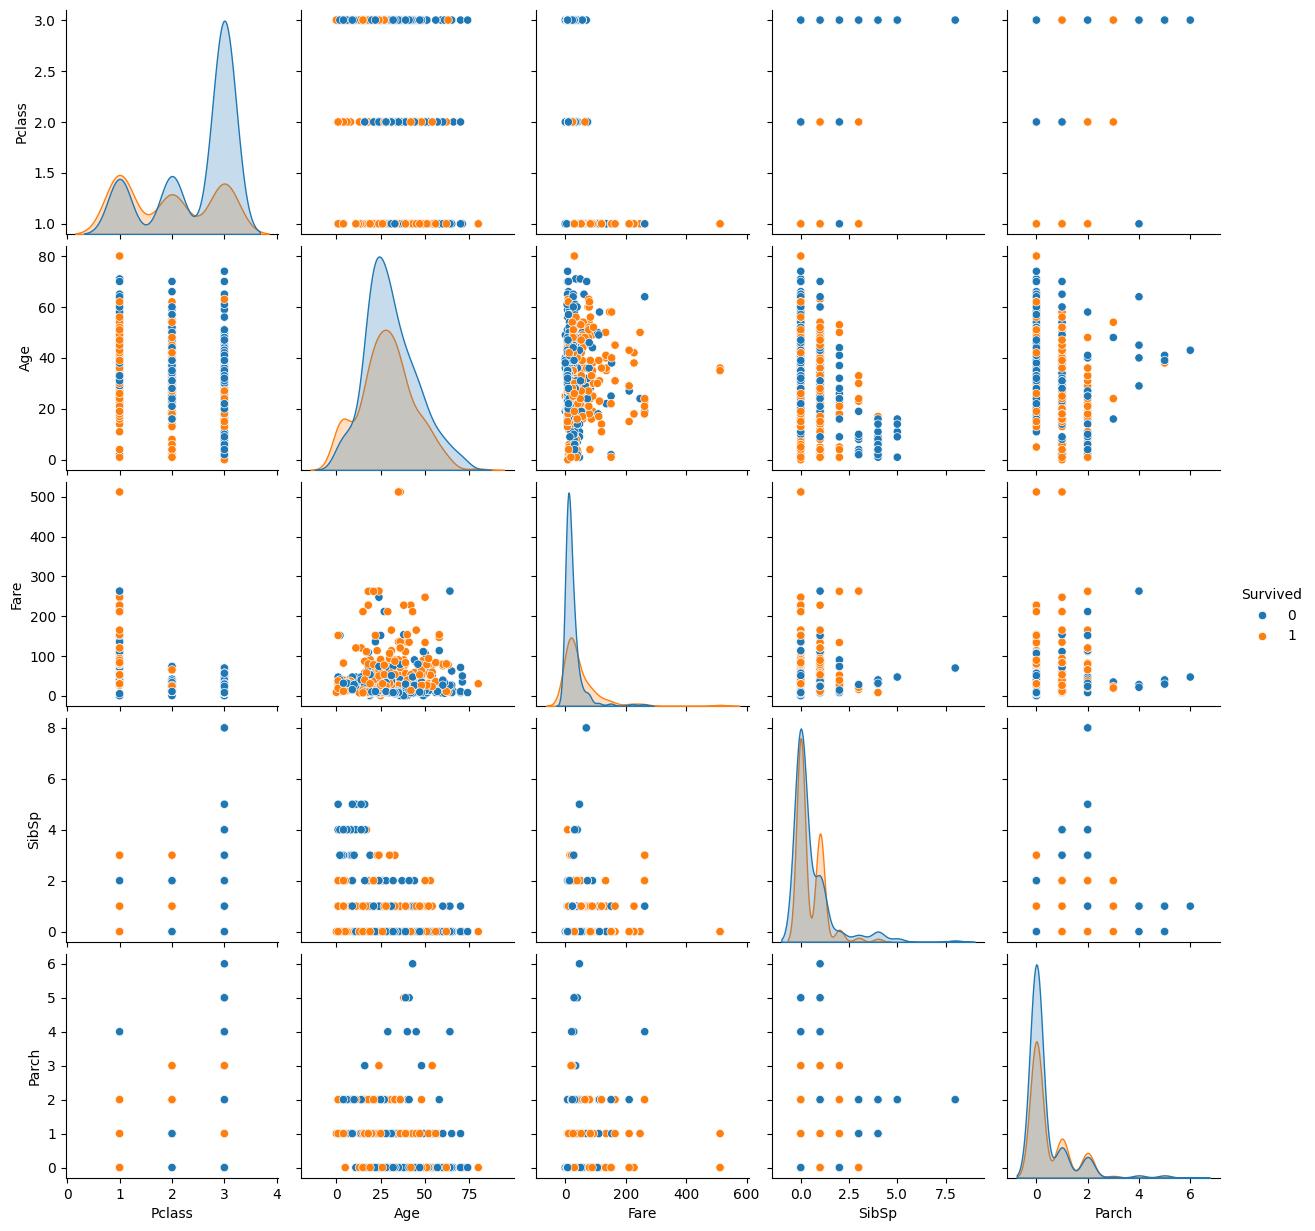

In [90]:
# Pairplot só com um subconjunto para facilitar a visualização
sns.pairplot(df_viz, vars=['Pclass','Age','Fare','SibSp','Parch'], hue='Survived')
plt.show()

**Conclusão das análises:**
- **Pclass**: grande relação com Survived — passageiros da 1ª classe sobreviveram em ~58% dos casos, contra ~21% na 3ª classe.
- **Sex**: relação com survived pois indica que as mulheres sobreviveram em ~69% dos casos, contra ~17% dos homens.
- **Age**: o boxplot mostra uma pequena diferença entre sobreviventes e não sobreviventes (crianças tendem a sobreviver mais). Tem correlação, mas não tanto.
- **SibSp e Parch**: correlação com Survived pequena, menor que o atributo anterior isoladamente, mas indicam o tamanho da família a bordo, o que pode interagir com chances de sobrevivência. Contexto familiar.
- **Fare**: correlação positiva (~0.27) com Survived, as tarifas maiores (associadas a classes melhores) aumentam a chance de sobrevivência.
- **Embarked**: porto de embarque pode estar correlacionado indiretamente com classe social e a origem dos passageiros. 

**Serão mantidos**
class, Sex, Age, SibSp, Parch, Fare, Embarked, por ter boa relacao com Survived.

# 3 - Preenchimento de Dados faltantes
**Aplique o algoritmo K-means no dataset2 para gerar clusters de tuplas com características semelhantes. Estime o melhor valor para k para obter os melhores clusters.**

Após a formatação e seleção das colunas relevantes, você deve garantir que todas as colunas estejam com dados válidos em cada coluna.

Para isso, você deve preencher os dados faltantes das colunas usando o algoritmo de agrupamento K-means.

Os passos desse processo são:

Passo 1: Crie um segundo dataset (dataset 2) sem as colunas com dados faltantes.

![Passo1](https://drive.google.com/uc?export=download&id=1dBpwbuWW-I_6_paIQNlfGER2ZZinZ59R)


Passo 2: Aplique o K-means no dataset 2 para gerar clusters de tuplas com características semelhantes.

![Passo2](https://drive.google.com/uc?export=download&id=1mNPNPdecWCqMraoS57a6TQKjkhGDgUHU)

Passo 3: Para cada cluster, selecione as tuplas que não possuam dados faltantes.

![Passo3](https://drive.google.com/uc?export=download&id=1xLwkPSjjxuZpW2zzk0k_-w3-AmvN84gj)

Passo 4: Para as tuplas selecionadas, calcula o atributo estatístico mais adequado para a coluna (média, mediana, moda, etc).

![Passo4](https://drive.google.com/uc?export=download&id=1zt35CNY_CWSGX_igHsA_AWKNZl34TM8K)

Passo 5: Para cada tupla com dados faltantes, utilize o atributo estatístico referente ao seu grupo para preencher o dado da coluna.

![Passo5](https://drive.google.com/uc?export=download&id=1rEvU-6eaQURjzIrblpIiA7b-FFYj_bRD)


In [91]:
# Tuplas e dados faltantes
target_cols = ['Pclass', 'Sex', 'Age', 'Embarked']
print(df[target_cols].isnull().sum())

missing_mask = df[target_cols].isnull().any(axis=1)
missing_ids = df[missing_mask].index.tolist()
print(f'\nValor total de tuplas que possuem algum atributo faltante: {len(missing_ids)}')

Pclass       67
Sex          67
Age         106
Embarked     69
dtype: int64

Valor total de tuplas que possuem algum atributo faltante: 165


In [92]:
ds2_cols = [c for c in df.columns if c not in target_cols]
dataset2 = df[ds2_cols].copy()
print(dataset2.isnull().sum())
dataset2.head().style.background_gradient(cmap='Blues')

Survived    0
SibSp       0
Parch       0
Fare        0
dtype: int64


,Survived,SibSp,Parch,Fare
0,0,1,0,7.250000
1,1,1,0,71.283300
2,1,0,0,7.925000
3,1,1,0,53.100000
4,0,0,0,8.050000


O dataset2 não possui valores faltantes em nenhuma coluna, então podemos aplicar o K-means diretamente após normalizar os dados (necessário para o K-means, pois ele se baseia em distância).

In [93]:
scaler_ds2 = MinMaxScaler()
dataset2_scaled = scaler_ds2.fit_transform(dataset2)
dataset2_scaled[:5]

array([[0.        , 0.125     , 0.        , 0.01415106],
       [1.        , 0.125     , 0.        , 0.13913574],
       [1.        , 0.        , 0.        , 0.01546857],
       [1.        , 0.125     , 0.        , 0.1036443 ],
       [0.        , 0.        , 0.        , 0.01571255]])

# K - means, a escolha do melhor K
*Elbow Method*

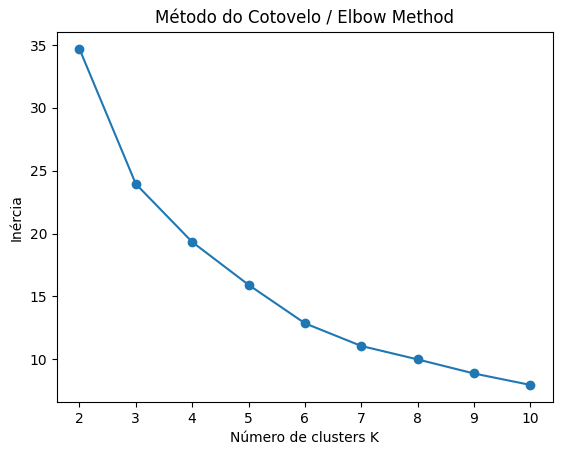

In [94]:
inertias = []
ks = range(2, 11)
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(dataset2_scaled)
    inertias.append(km.inertia_)

plt.plot(list(ks), inertias, marker='o')
plt.xlabel('Número de clusters K')
plt.ylabel('Inércia')
plt.title('Método do Cotovelo / Elbow Method')
plt.show()

Observando o gráfico, a curva apresenta uma inflexão (cotovelo) próxima de **K=5**, ponto a partir do qual a redução da inércia se torna menos acentuada. Por isso, o **K=5**.

In [95]:
best_k = 5
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(dataset2_scaled)
df['cluster'].value_counts()

cluster
0    396
3    218
1    109
2     32
4     28
Name: count, dtype: int64

**Cálculo do atributo estatístico por cluster e preenchimento**

Para cada coluna com dados faltantes (atributo-alvo), foi feito um cálculo com o melhor modelo estatístico direcionado para cada cluster, considerando apenas as tuplas do cluster que possuem valor definido para aquele atributo:

- **Age**: variável numérica contínua logo a **mediana** 
- **Pclass, Sex, Embarked**: variáveis categóricas/ordinais, o melhor modelo é a **moda**.

Então pude realizar o preenchimento cada tupla faltante com a estatística do cluster ao qual ela pertence.

In [96]:
for col in target_cols:
    if col == 'Age':
        stat_por_cluster = df.groupby('cluster')[col].median()
    else:
        stat_por_cluster = df.groupby('cluster')[col].agg(
            lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
    print(f'--- {col} ---')
    print(stat_por_cluster)

    df[col] = df.apply(
        lambda row: stat_por_cluster[row['cluster']] if pd.isnull(row[col]) else row[col],
        axis=1
    )

--- Pclass ---
cluster
0    3.0
1    2.0
2    3.0
3    1.0
4    3.0
Name: Pclass, dtype: float64
--- Sex ---
cluster
0    0.0
1    1.0
2    0.0
3    1.0
4    1.0
Name: Sex, dtype: float64
--- Age ---
cluster
0    30.0
1    22.0
2     7.5
3    30.0
4    37.5
Name: Age, dtype: float64
--- Embarked ---
cluster
0    S
1    S
2    S
3    S
4    S
Name: Embarked, dtype: object


In [97]:
df = df.drop(columns=['cluster'])
df.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

Agora que Embarked não possui mais valores faltantes, o one-hot encoding (que é uma variável nominal sem ordem entre as categorias).

# Solução via Claude
Não havia entendido como o one-hot encoding funcionava, a IA me mostrou que ele transforma uma coluna categórica de textos e categorias, em várias colunas binárias (0 ou 1) uma para cada categoria possível. Cada categoria tem um único 1 (na coluna de sua categoria) e nas outras é o próprio 0.
Logo modelos de machine learning trabalham com números, e se você simplesmente numerasse S=0, C=1, Q=2 (label encoding), o modelo poderia interpretar erroneamente que existe uma ordem ou distância entre as categorias (Q "maior" que S, por exemplo). O one-hot evita isso, tratando cada categoria de forma independente, sem hierarquia.

In [98]:
df = pd.get_dummies(df, columns=['Embarked'], prefix='Embarked')
embarked_cols = [c for c in df.columns if c.startswith('Embarked_')]
df[embarked_cols] = df[embarked_cols].astype(int)
df.head()


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
0,0,3.0,0.0,22.0,1,0,7.2500,0,0,1
1,1,1.0,1.0,38.0,1,0,71.2833,1,0,0
2,1,3.0,1.0,26.0,0,0,7.9250,0,0,1
3,1,1.0,1.0,35.0,1,0,53.1000,0,0,1
4,0,3.0,0.0,35.0,0,0,8.0500,0,0,1


In [ ]:
# Para confirmar as listas
df.columns.tolist()

['Survived',
 'Pclass',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Fare',
 'Embarked_C',
 'Embarked_Q',
 'Embarked_S']

In [99]:
df.dtypes

Survived        int64
Pclass        float64
Sex           float64
Age           float64
SibSp           int64
Parch           int64
Fare          float64
Embarked_C      int64
Embarked_Q      int64
Embarked_S      int64
dtype: object

# 4 - Escala dos atributos
**Identifique os clusters em que as tuplas com dados faltantes ficaram. Como as tuplas que estão no mesmo cluster são similares entre si, poderemos estimar valores para os atributos-alvo usando os valores pré-existentes desses atributos nas tuplas similares.**

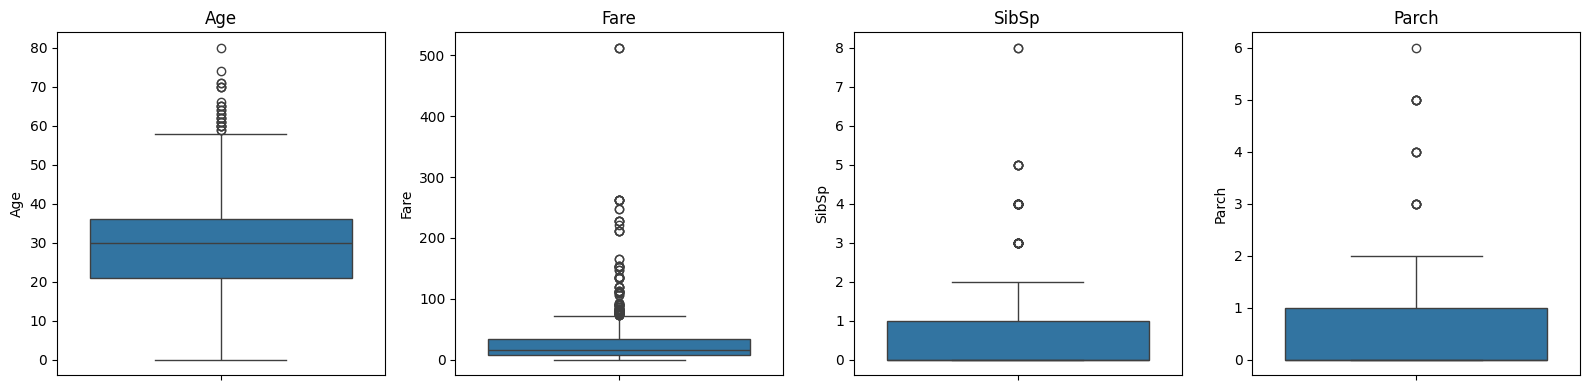

In [101]:
# Outliers
fig, axes = plt.subplots(1, 4, figsize=(16,4))
for ax, col in zip(axes, ['Age','Fare','SibSp','Parch']):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

A coluna Fare mostra outliers bem extremos (valores acima de 500), enquanto as colunas:
- Age
- SibSp
- Parch 
tem outliers menos extremos e que representam casos mais reais (famílias grandes, idades avançadas).

Para a coluna Fare, há uma técnica de **capping no percentil 99**, limitando os valores extremos sem descartar as linhas (evitando uma perda de dados).

Percentil 99 de Fare: 262.38


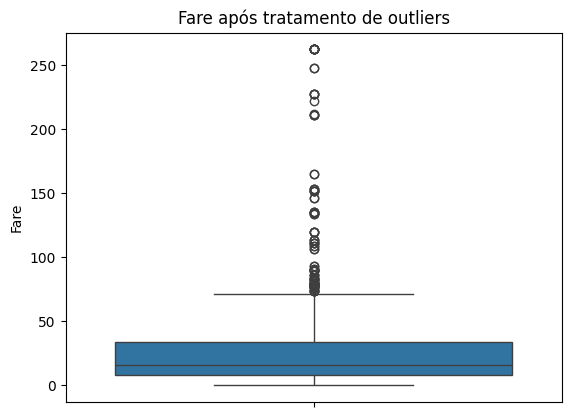

In [102]:
q99 = df['Fare'].quantile(0.99)
print(f'Percentil 99 de Fare: {q99:.2f}')
df['Fare'] = df['Fare'].clip(upper=q99)

sns.boxplot(y=df['Fare'])
plt.title('Fare após tratamento de outliers')
plt.show()

Reescala dos atributos

Aplicadas as **normalizações Min-Max** (intervalos [0,1]) nas colunas numéricas contínuas e ordinais (Pclass, Sex, Age, SibSp, Parch, Fare). As colunas Embarked_* já estão no intervalo [0,1] (one-hot) e a coluna Survived permanece inalterada por ser a variável alvo.

In [103]:
scale_cols = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']
scaler = MinMaxScaler()
df[scale_cols] = scaler.fit_transform(df[scale_cols])
df.describe()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
count,783.000000,783.000000,783.000000,783.000000,783.000000,783.000000,783.000000,783.000000,783.000000,783.000000
mean,0.417625,0.604087,0.402299,0.371919,0.065453,0.069391,0.128750,0.167305,0.071520,0.761175
std,0.493483,0.428772,0.490675,0.172695,0.123336,0.139554,0.172328,0.373487,0.257856,0.426638
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.262500,0.000000,0.000000,0.030681,0.000000,0.000000,1.000000
50%,0.000000,0.500000,0.000000,0.375000,0.000000,0.000000,0.060600,0.000000,0.000000,1.000000
75%,1.000000,1.000000,1.000000,0.450000,0.125000,0.166667,0.130340,0.000000,0.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# 5 - Balanceamento da coluna alvo
**Para cada cluster, aplique alguma técnica estatística tal como média, mediana ou moda sobre o atributo-alvo das tuplas similares, que possuem valor definido para este atributo. O valor resultante deve ser usado como novo valor do atributo faltante da tupla que está no mesmo cluster, mas que inicialmente seu atributo-alvo estava sem valor.**

In [104]:
# Desbalanceamento (?)
df['Survived'].value_counts()

Survived
0    456
1    327
Name: count, dtype: int64

A coluna alvo está um pouco desbalanceada (mais casos de não sobrevivência). O **oversampling aleatório** da classe minoritária (Survived = 1), mostra uma reposição até igualar o tamanho da classe majoritária. Essa técnica foi escolhida por ser simples, não exigir dependências externas e preservar todas as tuplas originais da classe majoritária. 
Ferramenta sugerida pela Claude IA (única IA usada como apoio).

In [105]:
majoritaria = df[df['Survived'] == 0]
minoritaria = df[df['Survived'] == 1]
minoritaria_upsampled = minoritaria.sample(n=len(majoritaria), replace=True, random_state=42)
df_balanced = pd.concat([majoritaria, minoritaria_upsampled])
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)
df_balanced['Survived'].value_counts()

Survived
1    456
0    456
Name: count, dtype: int64

# Verificação final e exportação do novo Dataset

Aqui deixo minhas considerações: esse projeto foi desafiador, principalmente com relação ao peso mental, mas agradeço a professora, que com sua didática e organização transformou o meu medo em alívio.

In [106]:
print('Shape final:', df_balanced.shape)
print('\nValores nulos:')
print(df_balanced.isnull().sum().sum())
print('\nLinhas duplicadas:', df_balanced.duplicated().sum())
print('\nTipos de dados:')
print(df_balanced.dtypes)
df_balanced.head()

Shape final: (912, 10)

Valores nulos:
0

Linhas duplicadas: 219

Tipos de dados:
Survived        int64
Pclass        float64
Sex           float64
Age           float64
SibSp         float64
Parch         float64
Fare          float64
Embarked_C      int64
Embarked_Q      int64
Embarked_S      int64
dtype: object


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
0,1,0.5,1.0,0.4250,0.000,0.000000,0.049547,0,0,1
1,1,1.0,1.0,0.3375,0.000,0.166667,0.047546,0,0,1
2,1,0.5,1.0,0.1000,0.000,0.333333,0.100048,0,0,1
3,0,0.0,0.0,0.3750,0.000,0.000000,0.101191,0,0,1
4,0,0.0,0.0,0.6125,0.125,0.166667,0.422614,1,0,0


In [108]:
df_balanced.to_csv('TitanicNovoDataset.csv', index=False)
print('Dataset salvo com sucesso!')

Dataset salvo com sucesso!


# Check-List

- Remoção das colunas que não acrescentam informações úteis;
- Todas as colunas estão com a sua representação unificada;
- Todas as colunas estão no formato numérico;
- Todas as colunas estão com dados válidos (sem dados falantes);
- Todas as colunas estão reescaladas;
- Coluna alvo balanceada.